In [6]:
import notebook_setup
import matplotlib.pyplot as plt
import numpy as np
import json
from plot_helper import create_strong_shading

from src.plot_style import set_plot_style

set_plot_style()

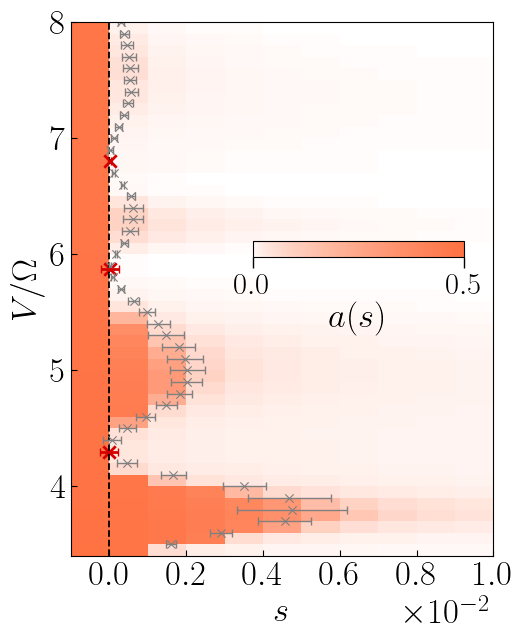

In [7]:
with open('data/phase_diagram_data.json', 'r') as f:
    data = json.load(f)
V_values = np.array(data["phase_diagram"]["V_values"])
s_range = np.array(data["phase_diagram"]["s_range"])
Z = np.array(data["phase_diagram"]["Z"])

s_cross_values = np.array(data["transition_line"]["s_cross"])
errors = np.array(data["transition_line"]["errors"])

highlight_points = data["highlight_points"]

ds = s_range[1] - s_range[0]
dV = V_values[1] - V_values[0]

s_edges = np.concatenate([[s_range[0] - ds], s_range])
V_edges = np.concatenate([[V_values[0] - dV], V_values])
X, Y = np.meshgrid(s_edges, V_edges)

from plot_helper import create_strong_shading
cmap_k, norm_k = create_strong_shading(
    color=(1.0, 0.443, 0.255),
    vmin=0,
    vmax=0.5,
    power=0.7
)

plt.figure(figsize=(5.4, 6.54))

c = plt.pcolormesh(X, Y, Z, shading='auto', cmap=cmap_k, norm=norm_k)

plt.scatter(s_cross_values, V_values, marker='x', c='grey', linewidths=0.8, zorder=2)
plt.errorbar(s_cross_values, V_values, xerr=errors, linestyle='None',
             capsize=3, elinewidth=1, c='grey', zorder=2)

for p in highlight_points:
    plt.scatter(p["s"], p["V"], marker='x', c='#d40000ff', s=80, linewidths=2.0)
    plt.errorbar(p["s"], p["V"], xerr=p["err"], linestyle='None',
                 capsize=3, elinewidth=2, c='#d40000ff', zorder=3)

plt.axvline(x=0, color='black', linewidth=1.3, linestyle='--', zorder=1)

ax = plt.gca()
cax = ax.inset_axes([0.43, 0.56, 0.5, 0.03])
cax.set_facecolor("none")
for spine in cax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(c, cax=cax, orientation="horizontal")
cbar.set_ticks([0, 0.5])
cbar.ax.tick_params(labelsize=22, direction='out', length=8, width=1.0)
cbar.ax.minorticks_off()
cbar.set_label(r"$a(s)$", fontsize=25, labelpad=1)

plt.xlabel(r"$s$", fontsize=25)
plt.ylabel(r"$V/\Omega$", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.gca().xaxis.get_offset_text().set_fontsize(25)

plt.savefig('figures/svg/fig1_c.svg', bbox_inches='tight', dpi=300, transparent=True)
plt.savefig('figures/pdf/fig1_c.pdf', bbox_inches='tight', dpi=300, transparent=True)

plt.tight_layout()
plt.show()